In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [4]:
amazon_product_df = pd.read_csv("C:/Users/Winifred/Ironhack/Part time program/Labs/Statistics Lab/lab EDA-bivariate/amz_uk_price_prediction_dataset.csv")

In [5]:
amazon_product_df.head(5)

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [6]:
amazon_product_df.dtypes

uid                    int64
asin                  object
title                 object
stars                float64
reviews                int64
price                float64
isBestSeller            bool
boughtInLastMonth      int64
category              object
dtype: object

In [11]:
amazon_product_df.isnull().count()

uid                  2443651
asin                 2443651
title                2443651
stars                2443651
reviews              2443651
price                2443651
isBestSeller         2443651
boughtInLastMonth    2443651
category             2443651
dtype: int64

In [18]:
amazon_product_df['category'].value_counts()

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [13]:
# Generating a crosstab for 'category' and 'isBestSeller'
crosstab_result = pd.crosstab(amazon_product_df['category'], amazon_product_df['isBestSeller'])

crosstab_result

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [17]:
bestseller_prop = pd.crosstab(amazon_product_df['category'], amazon_product_df['isBestSeller'],normalize='index')

bestseller_prop = bestseller_prop.sort_values(by=True, ascending=False)

print(bestseller_prop)

isBestSeller                         False     True 
category                                            
Grocery                           0.941865  0.058135
Smart Home Security & Lighting    0.942308  0.057692
Health & Personal Care            0.942314  0.057686
Mobile Phone Accessories          0.957529  0.042471
Power & Hand Tools                0.964661  0.035339
...                                    ...       ...
CD, Disc & Tape Players           1.000000  0.000000
General Music-Making Accessories  1.000000  0.000000
Snowboard Boots                   1.000000  0.000000
Boxes & Organisers                1.000000  0.000000
eBook Readers & Accessories       1.000000  0.000000

[296 rows x 2 columns]


The proportion of best-selling products varies across categories. Grocery, Smart Home Security & Lighting, and Health & Personal Care have the highest percentages of best-sellers (around 5.8%), while several categories have none. However, some of the top-ranked categories contain relatively few products, so their high proportions should be interpreted with caution. Overall, best-seller status is not evenly distributed across product categories.

In [19]:
from scipy.stats import chi2_contingency

# Chi-square test for ''category' and 'isBestSeller'
chi2_statistic, chi2_p_value, _, _ = chi2_contingency(crosstab_result)

chi2_statistic, chi2_p_value

(np.float64(36540.20270061387), np.float64(0.0))

The Chi-square test produced a statistic of 36,540.20 with a p-value < 0.001 (displayed as 0.0 due to numerical precision). Therefore, we reject the null hypothesis that product category and best-seller status are independent. This indicates a statistically significant association between product category and whether a product is a best-seller.

In [20]:
from scipy.stats.contingency import association

# Computing the association between variables in 'crosstab_result' using the "cramer" method
association(crosstab_result, method="cramer")

0.1222829439760564

The Chi-square test did not find a statistically significant association between product category and best-seller status (p > 0.05). Additionally, Cramér's V = 0.1223 indicates only a weak association, suggesting that best-seller status is largely independent of product category.

<Axes: xlabel='category'>

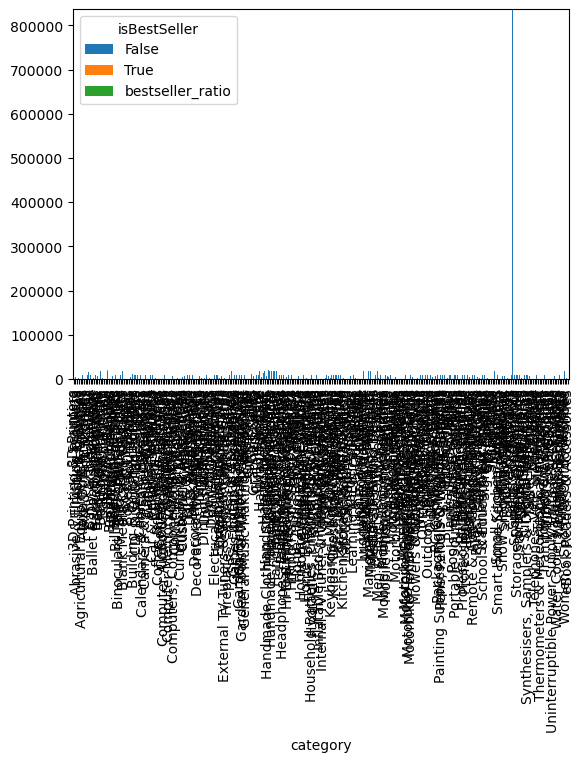

In [30]:
# Plotting a stacked bar chart for the 'crosstab_result' data
crosstab_result.plot(kind="bar", stacked=True)

In [25]:
crosstab_result = pd.crosstab(df['category'], df['isBestSeller'])

In [26]:
crosstab_result['bestseller_ratio'] = (crosstab_result[True] /crosstab_result.sum(axis=1))

In [27]:
top10 = crosstab_result.sort_values( by='bestseller_ratio',ascending=False).head(10)

In [28]:
top10_plot = top10.drop(columns='bestseller_ratio')

<Axes: xlabel='category'>

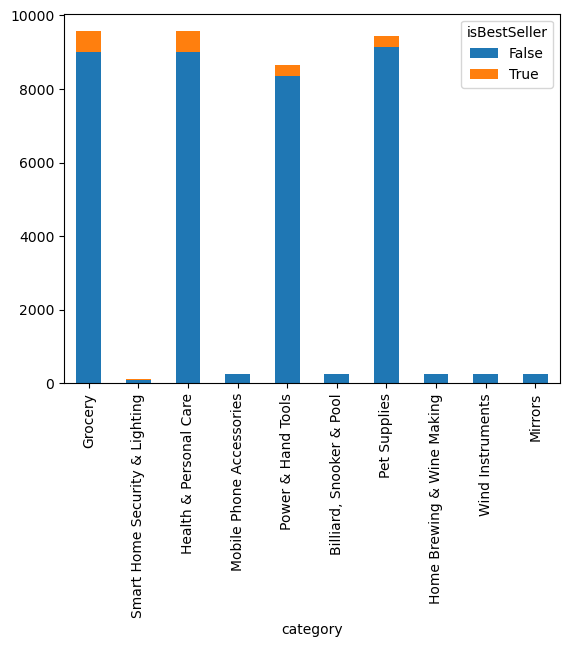

In [31]:
# Plotting a stacked bar chart for the 'crosstab_result' data
top10_plot.plot(kind="bar", stacked=True)

The stacked bar chart shows that non-best-selling products significantly outnumber best-selling products across all categories. While categories such as Grocery, Health & Personal Care, and Pet Supplies have the highest number of best-sellers, this appears largely driven by their larger product counts overall. Therefore, comparing best-seller proportions rather than raw counts provides a better assessment of category performance.

In [33]:
# Calculate IQR
Q1 = amazon_product_df['price'].quantile(0.25)
Q3 = amazon_product_df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define limits
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Remove outliers
df_no_outliers = amazon_product_df[(amazon_product_df['price'] >= lower) & (amazon_product_df['price'] <= upper)]

print(amazon_product_df.shape)
print(df_no_outliers.shape)

(2443651, 9)
(2115963, 9)


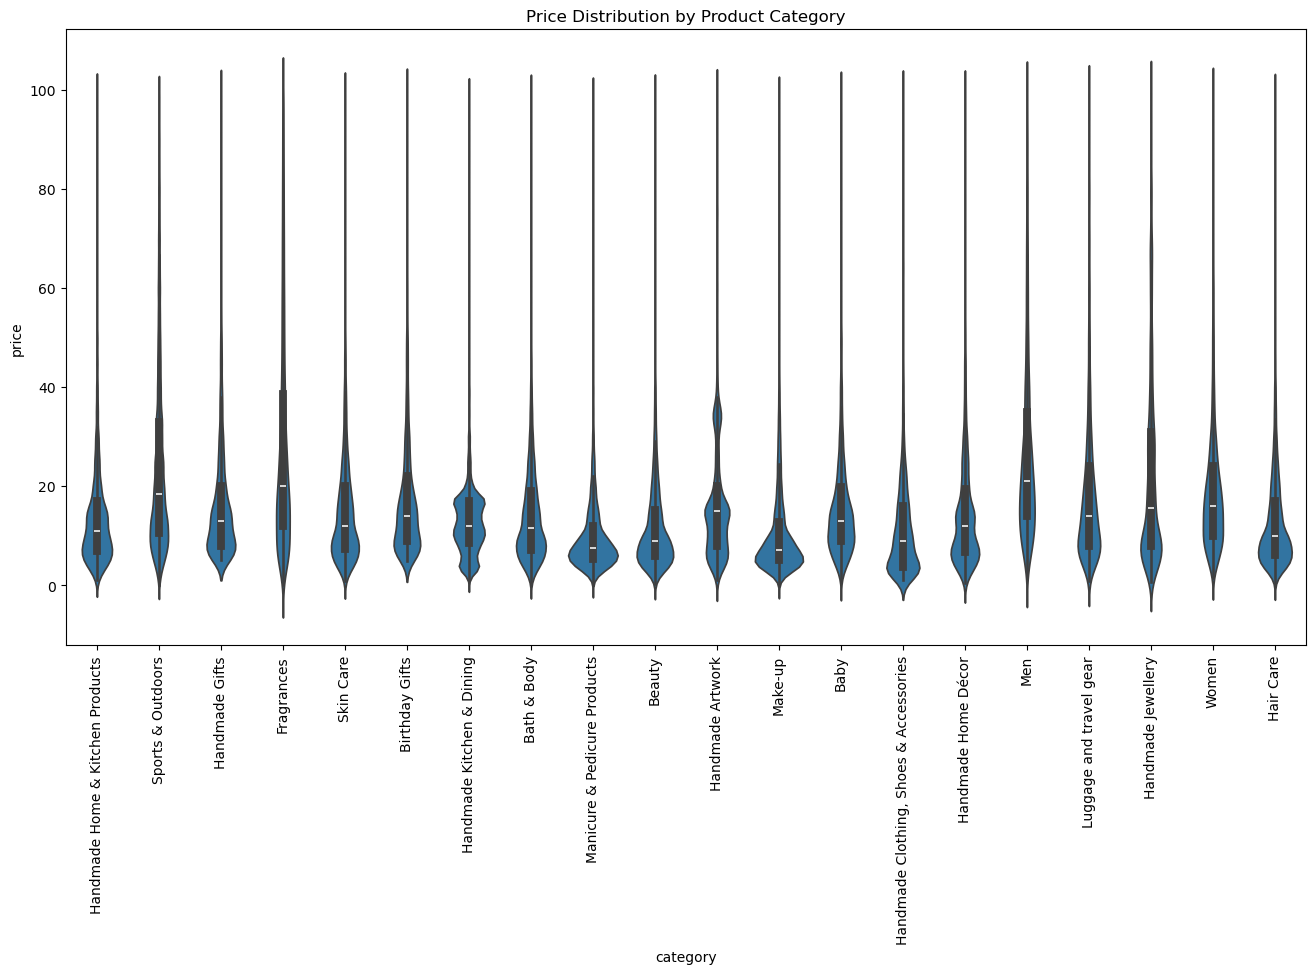

In [41]:
top20 = (
    df_no_outliers['category']
    .value_counts()
    .head(20)
    .index
)

plt.figure(figsize=(16,8))

sns.violinplot(
    data=df_no_outliers[df_no_outliers['category'].isin(top20)],
    x='category',
    y='price'
)

plt.xticks(rotation=90)
plt.title('Price Distribution by Product Category')
plt.show()

In [42]:
median_prices = (
    df_no_outliers
    .groupby('category')['price']
    .median()
    .sort_values(ascending=False)
)

print(median_prices.head(10))

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64


After removing price outliers using the IQR method, Desktop PCs have the highest median price among all product categories, with a median price of 74.00. This indicates that products in the Desktop PCs category are generally priced higher than those in other categories.

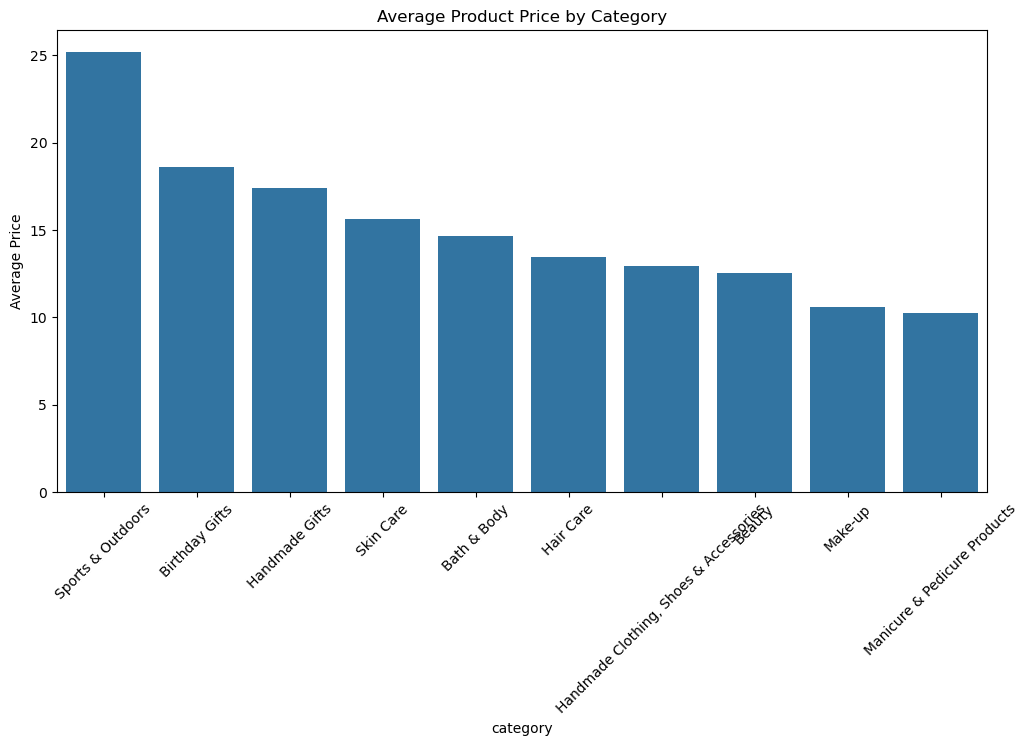

In [43]:
top10 = (
    df_no_outliers['category']
    .value_counts()
    .head(10)
    .index
)

avg_prices = (
    df_no_outliers[df_no_outliers['category'].isin(top10)]
    .groupby('category')['price']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_prices.index,
    y=avg_prices.values
)

plt.xticks(rotation=45)
plt.ylabel("Average Price")
plt.title("Average Product Price by Category")
plt.show()

In [44]:
highest_avg = (
    df_no_outliers
    .groupby('category')['price']
    .mean()
    .sort_values(ascending=False)
)

print(highest_avg.head(10))

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64


After removing price outliers using the IQR method, Motherboards have the highest average product price among all categories, with an average price of 68.77. This suggests that, on average, products in the Motherboards category are more expensive than those in other categories.

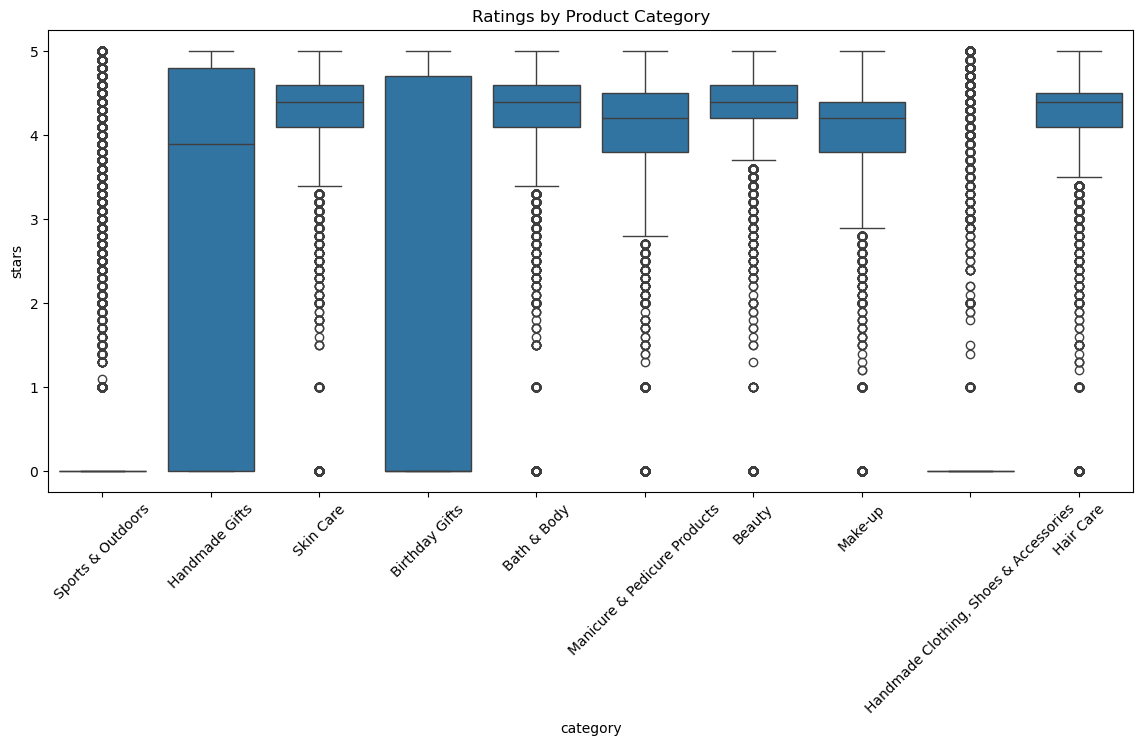

In [47]:
top10 = (
    df_no_outliers['category']
    .value_counts()
    .head(10)
    .index
)

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df_no_outliers[df_no_outliers['category'].isin(top10)],
    x='category',
    y='stars'
)

plt.xticks(rotation=45)
plt.title("Ratings by Product Category")
plt.show()

In [48]:
median_ratings = (
    df_no_outliers
    .groupby('category')['stars']
    .median()
    .sort_values(ascending=False)
)

print(median_ratings.head(10))

category
Computer Memory                 4.7
Building & Construction Toys    4.6
Office Paper Products           4.6
Luxury Food & Drink             4.6
Kids' Play Figures              4.6
Hobbies                         4.6
Beer, Wine & Spirits            4.6
Laptop Accessories              4.6
Cables & Accessories            4.5
CPUs                            4.5
Name: stars, dtype: float64


After removing price outliers using the IQR method, Computer Memory has the highest median customer rating, with a median rating of 4.7 stars. This indicates that products in this category receive the highest overall customer satisfaction compared to other categories.

In [49]:
correlation = df_no_outliers['price'].corr(df_no_outliers['stars'])

print("Correlation between price and stars:", correlation)

Correlation between price and stars: -0.0776729987818137


The Pearson correlation coefficient between price and stars is -0.078 (approximately). This indicates a very weak negative linear relationship between product price and customer ratings. Since the value is very close to zero, there is no significant correlation between the two variables. In other words, more expensive products do not necessarily receive higher or lower ratings than less expensive products.

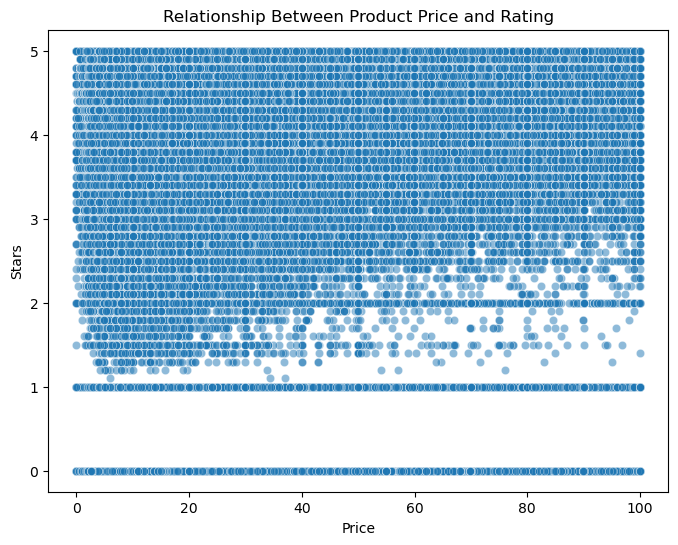

In [50]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_no_outliers,
    x='price',
    y='stars',
    alpha=0.5
)

plt.title("Relationship Between Product Price and Rating")
plt.xlabel("Price")
plt.ylabel("Stars")
plt.show()

The scatter plot does not display a clear linear relationship between product price and customer ratings. Ratings remain relatively consistent across different price ranges, indicating that higher-priced products do not necessarily receive better customer ratings.

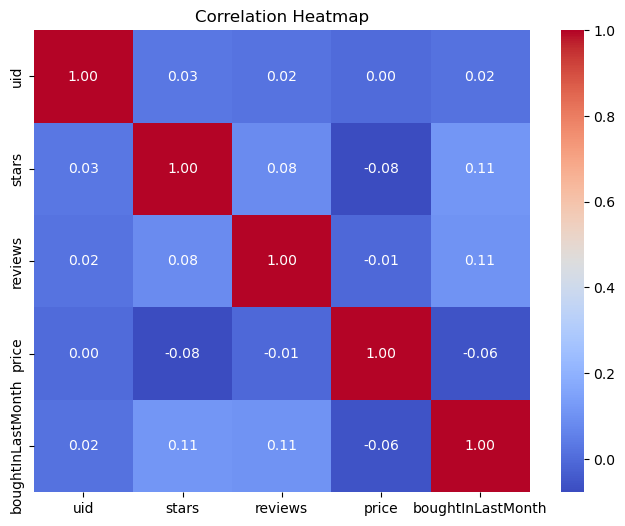

In [52]:
numeric_df = df_no_outliers.select_dtypes(include='number')

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

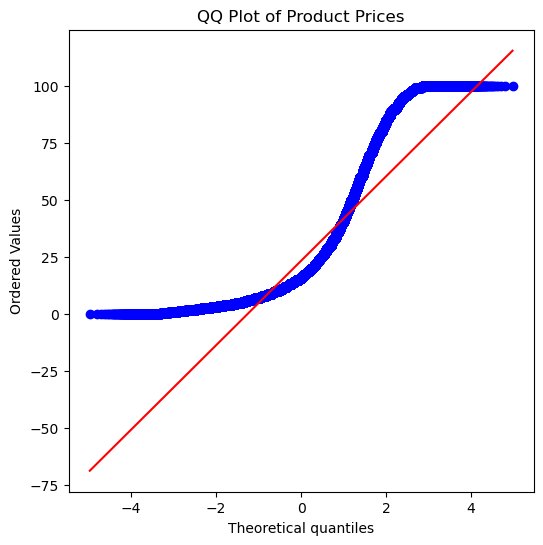

In [54]:
from scipy import stats
plt.figure(figsize=(6,6))

stats.probplot(df_no_outliers['price'], dist='norm', plot=plt)

plt.title("QQ Plot of Product Prices")
plt.show()

The deviations from the reference line suggest that product prices are skewed and do not satisfy the assumption of normality. Even after removing outliers using the IQR method, the price distribution remains non-normal.

In [55]:
correlation = df_no_outliers['price'].corr(df_no_outliers['stars'])
print(correlation)

-0.0776729987818137


The Pearson correlation coefficient between price and customer ratings (stars) is -0.078. This indicates a very weak negative correlation between product price and customer ratings. Since the correlation coefficient is very close to zero, there is no significant linear relationship between the two variables. Therefore, product price does not appear to have a meaningful impact on customer ratings.